In [1]:
# IPython extension to reload modules before executing user code.
# useful to see immediate results in notebook when modifying imported scripts
%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np
import pandas as pd
from scipy.stats import binom_test

import sys
import os

# Add the ../py directory to sys.path
# This allows importing modules from the py directory as if they were in the current directory
module_path = os.path.abspath(os.path.join(os.getcwd(), '..', 'py'))
if module_path not in sys.path:
    sys.path.append(module_path)

# Verify it works
print(f"Added to path: {module_path}")

Added to path: /Users/eyal/projects/elzurdo/precision-goal/py


In [69]:
from utils_experiments import (
    BinaryPvalueAccounting,
    BinomialSimulation,
    sequence_to_sequential_pvalues,
    stop_decision_multiple_experiments_nhst,
    SEQUENCE_HANDPICKED
    # BinomialHypothesis,
    # stop_decision_multiple_experiments_multiple_methods,
    # stats_dict_to_df,
    # iteration_counts_to_df,
    # sample_all_iterations_results,
    # report_success_rates_multiple_algos,
    # run_simulations_and_analysis_report, # was called full_analysis

)

from utils_viz import (
    plot_decision_rates_nhst
)


SEED = 42

In [4]:
import matplotlib.pyplot as plt
SMALL_SIZE = 12
MEDIUM_SIZE = 16
BIGGER_SIZE = 20

FIG_WIDTH, FIG_HEIGHT = 8, 6

plt.rc("font", size=SMALL_SIZE)  # controls default text sizes
plt.rc("axes", titlesize=SMALL_SIZE)  # fontsize of the axes title
plt.rc("axes", labelsize=MEDIUM_SIZE)  # fontsize of the x and y labels
plt.rc("xtick", labelsize=SMALL_SIZE)  # fontsize of the tick labels
plt.rc("ytick", labelsize=SMALL_SIZE)  # fontsize of the tick labels
plt.rc("legend", fontsize=SMALL_SIZE)  # legend fontsize
plt.rc("axes", titlesize=BIGGER_SIZE)  # fontsize of the figure title

plt.rcParams["figure.figsize"] = FIG_WIDTH, FIG_HEIGHT
# plt.rcParams["hatch.linewidth"] = 0.2

plt.rcParams['axes.spines.right'] = False
plt.rcParams['axes.spines.top'] = False

# Aux

In [32]:
# used for storing an linking to binary calucations already performed
binary_accounting = BinaryPvalueAccounting()

# Hypothesis

In [33]:
success_rate_null = 0.5
p_value_thresh = 0.05 #i.e, alpha #0.001 #0.001 #0.01 #0.05 # 0.0001 #0.05

# Simulations

In [34]:
N_EXPERIMENTS = 50 # 2000
N_SAMPLES = 30000 #1500  # in paper called M

## Fair Coin ($\theta_{\rm true} = 0.5$)

In [35]:
fair_coin_rate = 0.5

In [36]:
%%time

synth_0pt5 = BinomialSimulation(
    success_rate=fair_coin_rate,
    n_samples = N_SAMPLES,
    n_experiments = N_EXPERIMENTS,
    seed=SEED)

Generating synthetic data with parameter values:
0.5: true success rate
50: experiments
30000: sample size per experiment
CPU times: user 35 ms, sys: 3.86 ms, total: 38.8 ms
Wall time: 38 ms


In [38]:
# sequence = synth_0pt5.experiments[0]
sequence = np.array([int(value)for value in SEQUENCE_HANDPICKED[:N_SAMPLES]])
p_values = sequence_to_sequential_pvalues(sequence)

62


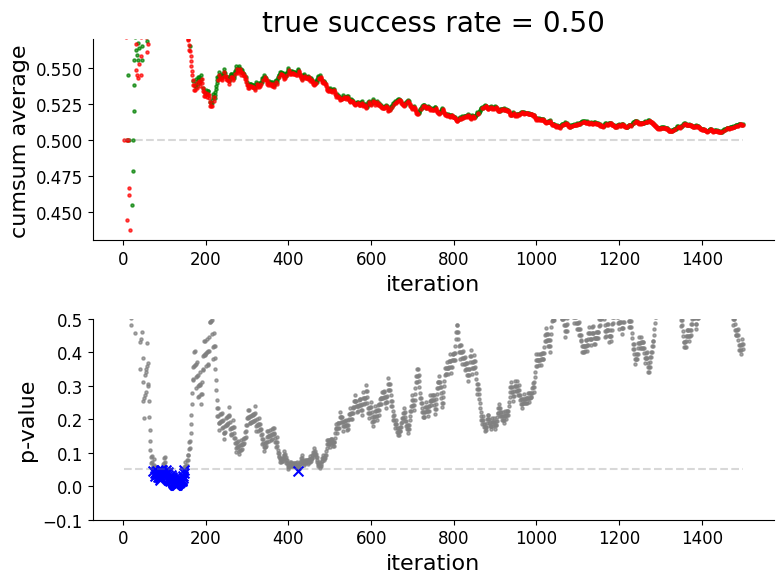

In [39]:

# ----------
xlabel = "iteration"
title = f"true success rate = {synth_0pt5.success_rate:0.2f}"
msize = 5
dsuccess_rate_plot = 0.07

sequence_idx = np.arange(len(sequence))+ 1
sequence_average = sequence.cumsum() / sequence_idx

plt.subplot(2, 1, 1)

#errorbar = 1.96 * np.sqrt((sequence_average * (1. - sequence_average)) / sequence_idx )
#plt.errorbar(sequence_idx, sequence_average, yerr=errorbar, color="gray", alpha=0.05)
plt.scatter(sequence_idx[sequence == 1], sequence_average[sequence == 1], color = "green", alpha=0.7, s=msize)
plt.scatter(sequence_idx[sequence == 0], sequence_average[sequence == 0], color = "red", alpha=0.7, s=msize)
plt.hlines(synth_0pt5.success_rate, sequence_idx[0], sequence_idx[-1], color="gray", linestyle='--', alpha=0.3)
plt.xlabel(xlabel)
plt.ylabel("cumsum average")
plt.ylim(synth_0pt5.success_rate - dsuccess_rate_plot, synth_0pt5.success_rate + dsuccess_rate_plot)
plt.title(title)


plt.subplot(2, 1, 2)
plt.hlines(p_value_thresh, sequence_idx[0], sequence_idx[-1], color="gray", linestyle='--', alpha=0.3)
plt.scatter(sequence_idx[p_values >= p_value_thresh], p_values[p_values >= p_value_thresh], color = "gray", alpha=0.7, s=msize)
plt.scatter(sequence_idx[p_values < p_value_thresh], p_values[p_values < p_value_thresh], color = "blue", marker='x', s=msize * 10)
plt.xlabel(xlabel)
plt.ylabel("p-value")
plt.ylim(-0.1, 0.5)


plt.tight_layout()
print(len(sequence_idx[p_values < p_value_thresh]))

## Many Experiments

In [47]:
synth_0pt5 = BinomialSimulation(
    success_rate=fair_coin_rate,
    n_samples = N_SAMPLES,
    n_experiments = N_EXPERIMENTS,
    seed=SEED)

Generating synthetic data with parameter values:
0.5: true success rate
50: experiments
30000: sample size per experiment


In [48]:
hypo_0pt5_results = stop_decision_multiple_experiments_nhst(
experiments= synth_0pt5.experiments,
p_value_thresh= p_value_thresh,
success_rate_null= success_rate_null,
alternative= 'two-sided',
binary_pvalue_accounting= binary_accounting,
) 

hypo_0pt5_results.keys()

dict_keys(['iteration_stopping_on_or_prior', 'experiment_stop_results'])

In [101]:
hypo_0pt5_results['experiment_stop_results'].keys()

dict_keys(['successes', 'trials', 'p_value'])

In [105]:
df_experiment_stats = pd.DataFrame(hypo_0pt5_results['experiment_stop_results'])
df_experiment_stats.index.name = 'experiment_number'
df_experiment_stats['sample_success_rate'] = df_experiment_stats['successes'] * 1. / df_experiment_stats['trials']


print(df_experiment_stats.shape)
df_experiment_stats.head(4)

(50, 4)


,successes,trials,p_value,sample_success_rate
experiment_number,,,,
0,15010,30000,0.912650,0.500333
1,14999,30000,0.995393,0.499967
2,19,54,0.040224,0.351852
3,9,30,0.042774,0.300000


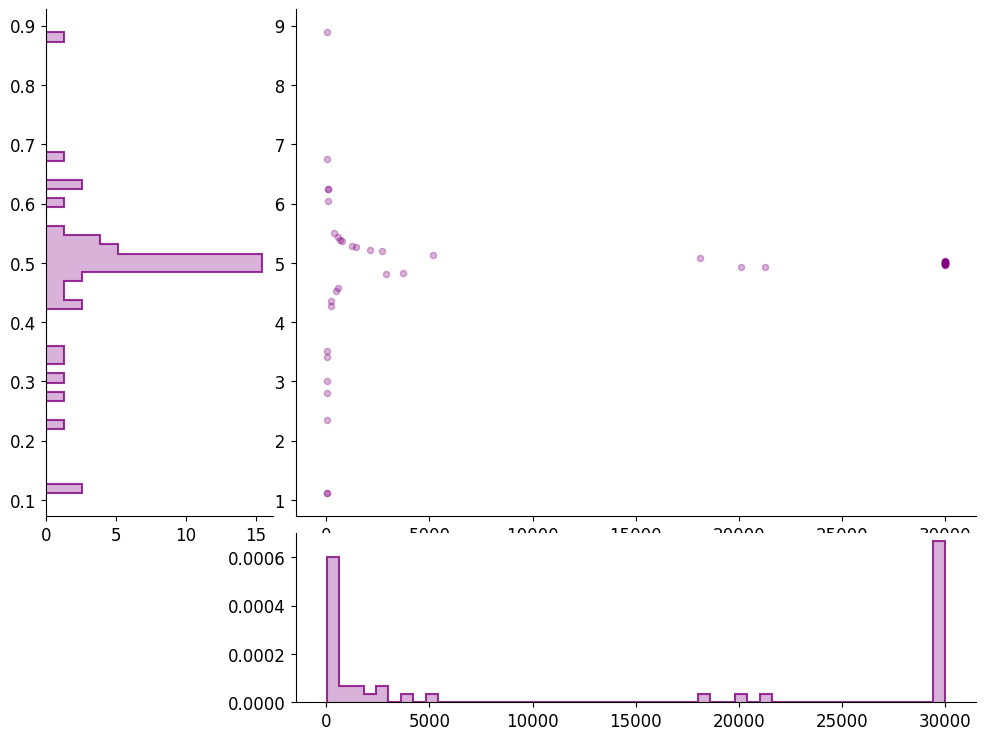

In [119]:
import matplotlib.gridspec as gridspec

scatter_ratio = 3

fig = plt.figure(figsize=(FIG_WIDTH * 1.5, FIG_HEIGHT * 1.5))

gs = gridspec.GridSpec(2, 2, width_ratios=[1, scatter_ratio], height_ratios=[scatter_ratio, 1], 
                        wspace=0.05, hspace=0.05)

ax_scatter = fig.add_subplot(gs[0, 1])
ax_left = fig.add_subplot(gs[0, 0], sharey=ax_scatter)
ax_bottom = fig.add_subplot(gs[1, 1], sharex=ax_scatter)


color = "purple"
ax_scatter.scatter(df_experiment_stats["trials"], df_experiment_stats["sample_success_rate"], 
                           alpha=0.3, color=color, label=None, marker=None, s=20)


# --- Bottom Panel: Iteration Histogram ---
# Calculate histogram first to capture densities
bins = 50
iter_counts, iter_bins = np.histogram(df_experiment_stats["trials"], bins=bins, density=True)
#iteration_max_densities.append(np.max(iter_counts))

ax_bottom.hist(df_experiment_stats["trials"], bins=bins, color=color, alpha=0.3, 
                density=True, histtype='stepfilled')
ax_bottom.hist(df_experiment_stats["trials"], bins=bins, color=color, alpha=0.8, 
                density=True, histtype='step', linewidth=1.5)


# --- Left Panel: Success Rate Histogram ---
success_counts, success_bins = np.histogram(df_experiment_stats["sample_success_rate"], bins=bins, density=True)


ax_left.hist(df_experiment_stats["sample_success_rate"], bins=bins, color=color, alpha=0.3, 
                density=True, histtype='stepfilled', orientation='horizontal')
ax_left.hist(df_experiment_stats["sample_success_rate"], bins=bins, color=color, alpha=0.8, 
                density=True, histtype='step', orientation='horizontal', linewidth=1.5)
pass

In [81]:
synth_0pt5.__dict__.keys()

/Users/eyal/projects/elzurdo/precision-goal/py/utils_viz.py:923: SyntaxWarning: "is not" with a literal. Did you mean "!="?
  # stop ratio


dict_keys(['success_rate', 'n_samples', 'n_experiments', 'seed', 'experiments'])

30000

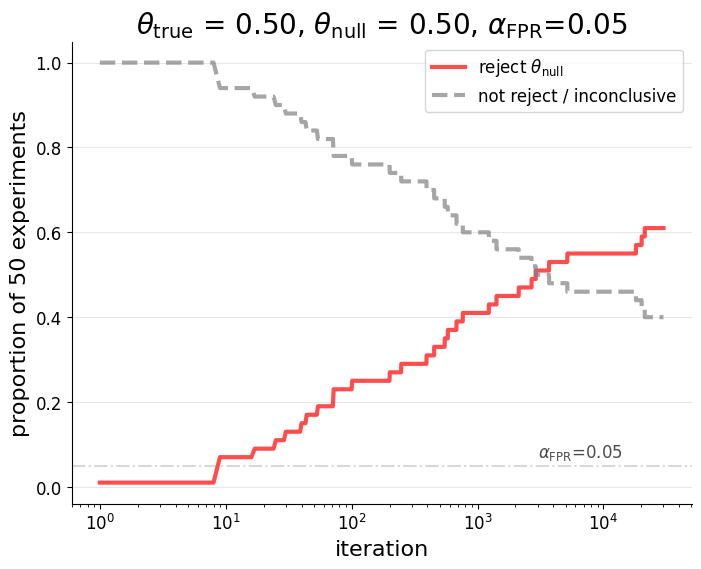

In [98]:
plot_decision_rates_nhst(N_EXPERIMENTS, hypo_0pt5_results['iteration_stopping_on_or_prior'],
 fpr=p_value_thresh, success_rate_true=synth_0pt5.success_rate, success_rate_null=synth_0pt5.success_rate)
plt.savefig("../latex/images/fair_experiment_decision_rates_nhst.png")


In [53]:
len(binary_accounting.dict_successes_n_pvalue.keys())

620220

In [56]:
list(binary_accounting.dict_successes_n_counter.keys())[2]

(2, 3)

In [57]:
binary_accounting.dict_successes_n_counter[(2,3)]

22

In [60]:
hypo_0pt5_results.keys()

dict_keys(['iteration_stopping_on_or_prior', 'experiment_stop_results'])

In [68]:
pd.Series(hypo_0pt5_results['experiment_stop_results']['trials']).describe(percentiles=np.arange(0, 1.1, 0.1))

count       50.000000
mean     13661.560000
std      14228.249733
min          9.000000
0%           9.000000
10%         29.500000
20%         72.000000
30%        435.300000
40%       1043.600000
50%       3300.000000
60%      24773.400000
70%      30000.000000
80%      30000.000000
90%      30000.000000
100%     30000.000000
max      30000.000000
dtype: float64

(array([25.,  2.,  0.,  0.,  0.,  0.,  2.,  1.,  0., 20.]),
 array([9.00000e+00, 3.00810e+03, 6.00720e+03, 9.00630e+03, 1.20054e+04,
        1.50045e+04, 1.80036e+04, 2.10027e+04, 2.40018e+04, 2.70009e+04,
        3.00000e+04]),
 <BarContainer object of 10 artists>)

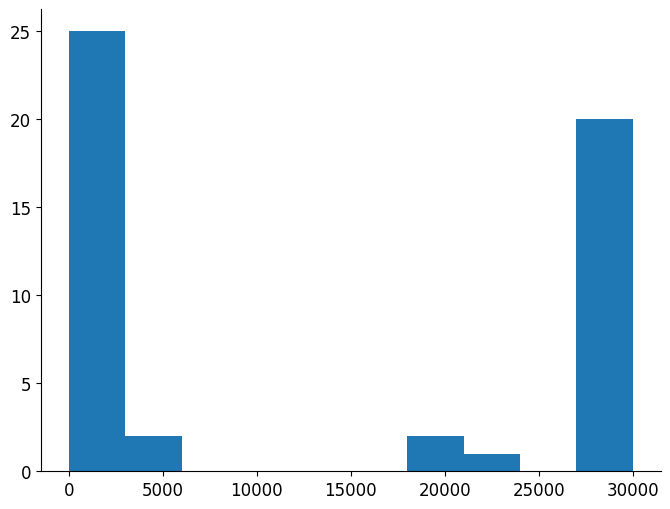

In [64]:
plt.hist(hypo_0pt5_results['experiment_stop_results']['trials'])

In [59]:
hypo_0pt5_results['experiment_stop_results']['p_value']

[0.912650274467657,
 0.995393449728459,
 0.04022356409571669,
 0.042773945257067694,
 0.04833795946747931,
 0.4920538594237201,
 0.8398603934544872,
 0.912650274467657,
 0.4920538594237201,
 0.04973778353424493,
 0.04990963870749309,
 0.04437092000802569,
 0.6483139649001992,
 0.04907849719366794,
 0.043285250663757324,
 0.049806982489211844,
 0.04829578821948266,
 0.04437092000802569,
 0.15721159956395844,
 0.048766765904474596,
 0.04634646271863101,
 0.04911922423027103,
 0.04653881020185072,
 0.6154609465594552,
 0.049300517915689464,
 0.7861188330186143,
 0.0390625,
 0.04904574503301471,
 0.0390625,
 0.34077873768573347,
 0.049041748046875,
 0.04997618952446773,
 0.46341578250645843,
 0.3123213937311348,
 0.12890434194711597,
 0.03847730828420026,
 0.0484747024978393,
 0.04800146605383198,
 0.04909099628627713,
 0.4156087939625459,
 0.04952030856547906,
 0.665006252125149,
 0.6988866811261235,
 0.0390625,
 0.5993137104225927,
 0.7684156768047665,
 0.04622096112691611,
 0.6154609465

In [91]:
%%time




# NHST stop criterion:
# For every new flip of the coin, stop and reject the null hypothesis, that θ=0.50, if p < .05 (two-tailed, conditionalizing on the current N), otherwise flip again.

# used for to show that success_rate = 0.5 can go higher than 50%
#experiments = 50 # 200
#n_samples = 30000

# experiments = 1000 #200
# n_samples = 350 #1500

alternative = 'two-sided' # 'greater'
# ----------

experiement_stop_results = {'successes': [], 'trials': [], 'p_value': []}
iteration_stopping_on_or_prior = {iteration: 0 for iteration in range(1, synth_0pt5.n_samples + 1)}

#np.random.seed(seed)
#samples = np.random.binomial(1, success_rate, [experiments, n_samples])

for sequence in synth_0pt5.experiments:
    successes = 0
    this_iteration = 0
    for toss in sequence:
        successes += toss
        this_iteration += 1
        
        # Using this instead of `sequence_to_sequential_pvalues` due to sotpping
        p_value = binom_test(successes, n=this_iteration, p=success_rate_null, alternative=alternative)
        
        if p_value < p_value_thresh:
            for iteration in range(this_iteration, synth_0pt5.n_samples+1):
                iteration_stopping_on_or_prior[iteration] += 1
                
            break
    experiement_stop_results['successes'].append(successes)
    experiement_stop_results['trials'].append(this_iteration)
    experiement_stop_results['p_value'].append(p_value)

<timed exec>:28: DeprecationWarning: 'binom_test' is deprecated in favour of 'binomtest' from version 1.7.0 and will be removed in Scipy 1.12.0.
/Users/eyal/.pyenv/versions/scrappy-3.8.11/lib/python3.8/site-packages/scipy/stats/_discrete_distns.py:77: RuntimeWarning: divide by zero encountered in _binom_pdf
  return _boost._binom_pdf(x, n, p)


CPU times: user 12min 13s, sys: 2.03 s, total: 12min 15s
Wall time: 15min 1s


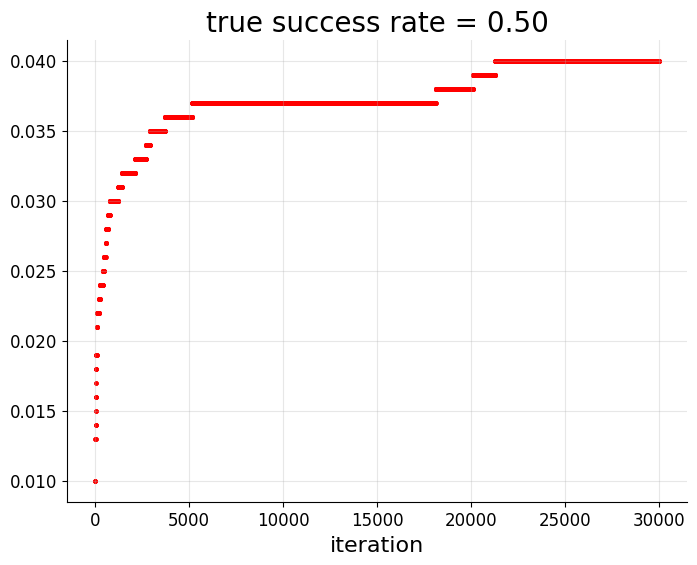

In [100]:
sr_iteration_stopping_on_or_prior = pd.Series(iteration_stopping_on_or_prior)
sr_nhst_reject = sr_iteration_stopping_on_or_prior / experiments

plt.scatter(sr_nhst_reject.index, sr_nhst_reject + 0.01, alpha=0.7, s=msize, color="red")
#plt.scatter(sr_nhst_reject.index, 1. - sr_nhst_reject, alpha=0.7, s=msize, color="gray")

#plt.xscale('log')
plt.xlabel(xlabel)
plt.title(title)
plt.grid(alpha=0.3)

Text(0.5, 1.0, 'true success rate = 0.50')

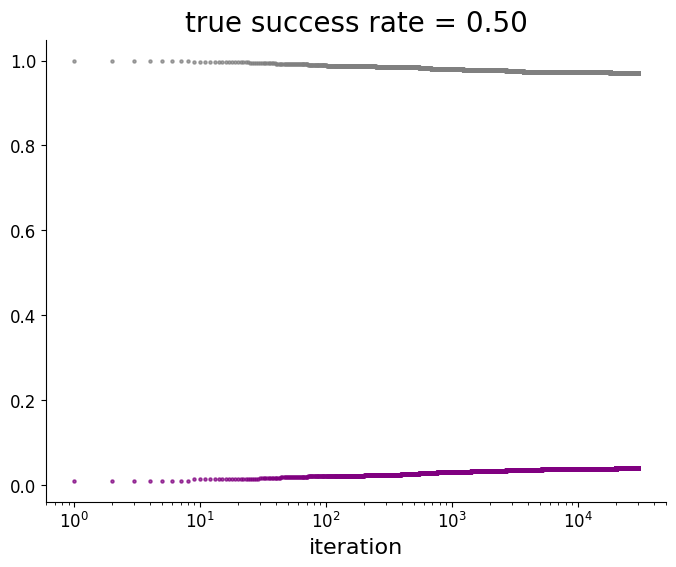

In [93]:
sr_iteration_stopping_on_or_prior = pd.Series(iteration_stopping_on_or_prior)
sr_nhst_reject = sr_iteration_stopping_on_or_prior / experiments

plt.scatter(sr_nhst_reject.index, sr_nhst_reject + 0.01, alpha=0.7, s=msize, color="purple")
plt.scatter(sr_nhst_reject.index, 1. - sr_nhst_reject, alpha=0.7, s=msize, color="gray")

plt.xscale('log')
plt.xlabel(xlabel)
plt.title(title)

count       30.000000
mean      2769.266667
std       5935.159347
min          9.000000
25%         46.500000
50%        423.500000
75%       1946.750000
max      21289.000000
Name: trials, dtype: float64
0.47197791823949165
0.5002873088694917


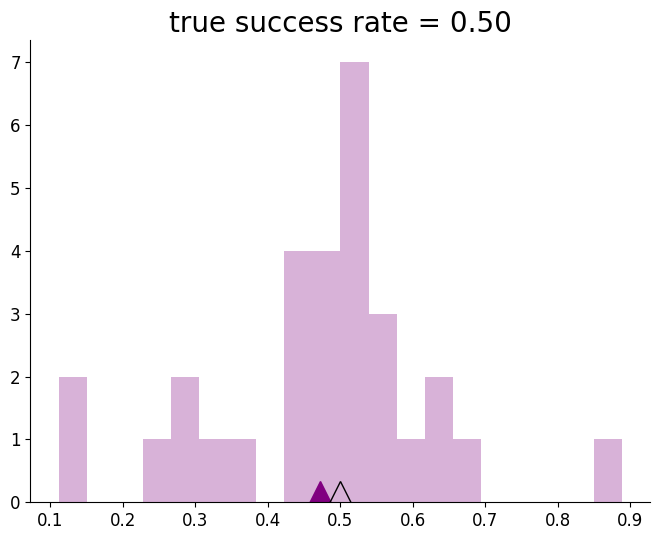

In [94]:
df_stop_results = pd.DataFrame(experiement_stop_results)
df_stop_results.index.name = 'experiment_number'
df_stop_results['sample_success_rate'] = df_stop_results['successes'] * 1. / df_stop_results['trials']

df_plot = df_stop_results.copy()

df_plot = df_plot.query("p_value < @p_value_thresh")

#df_plot = df_stop_results.query(f"trials < {df_stop_results['trials'].describe()['25%'] / 2}").copy()

#print(len(df_plot))
print(df_plot['trials'].describe())
mean_success_rate = df_plot['sample_success_rate'].mean()

plt.hist(df_plot['sample_success_rate'], alpha=0.3, color="purple", bins=20)
print(mean_success_rate)
print(df_plot['sample_success_rate'].median())
#plt.scatter([mean_success_rate], [0], marker='^', s=400,color="red")
#plt.scatter([success_rate], [0], marker='^', s=400,color="black", alpha=0.1)

marker_style = dict(color='purple', linestyle=':', marker='^',
                    markersize=30, markerfacecoloralt='tab:red')
plt.plot([mean_success_rate], [0], **marker_style)

marker_style = dict(color='black', linestyle=':', marker='^',
                    markersize=30, markerfacecoloralt='tab:black')
plt.plot([synth_0pt5.success_rate], [0], fillstyle='none' , **marker_style)

plt.title(title)
pass

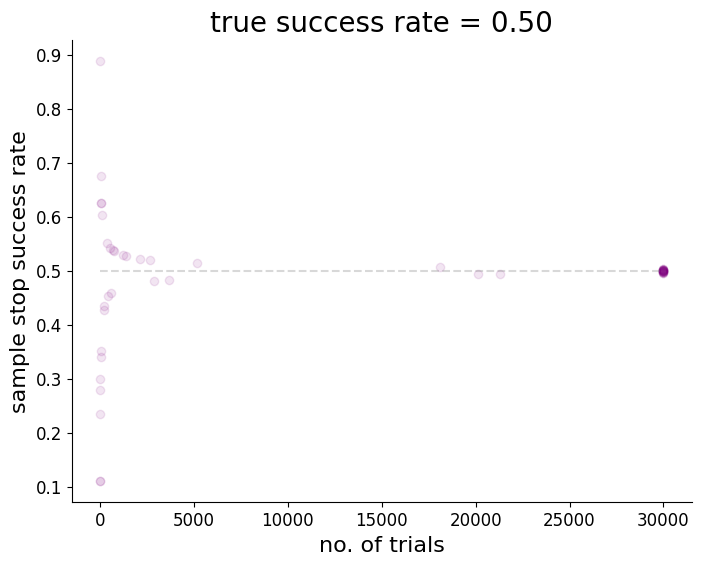

In [95]:
plt.scatter(df_stop_results['trials'], df_stop_results['sample_success_rate'], color="purple", alpha=0.1)
plt.xlabel('no. of trials')
plt.ylabel('sample stop success rate')
plt.title(title)
plt.hlines(synth_0pt5.success_rate, 0, df_stop_results['trials'].max() + 1, color="gray", linestyle='--', alpha=0.3)

<Axes: >

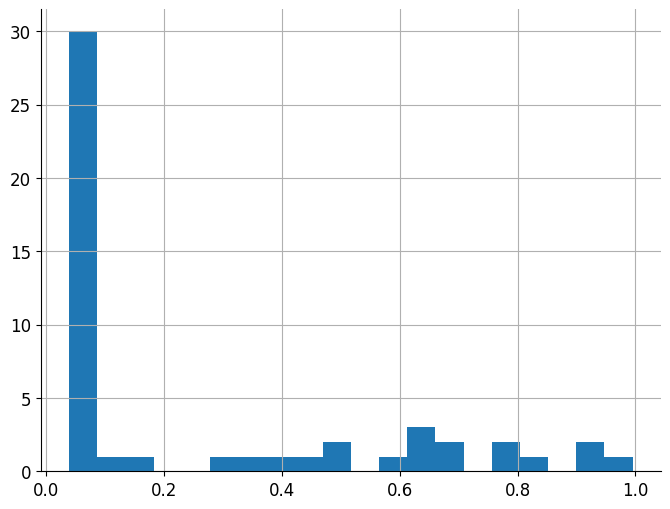

In [96]:
df_plot = df_stop_results.copy()

df_plot['p_value'].hist(bins=20)